# Ginger Pest & Disease Classification — MobileNetV2 Transfer Learning

**Dataset:** 9 classes from `ginger_plant_dataset/combined/`  
**Classes:** Damage-Pest, Dehydrated, Healthy, Leaf roller, Leaf-blight,  
           Mite infestation, Rhizome scale, Shoot borer, Thrips  
**Output:** `ginger_pest_model.tflite` — download and place in `streamlit_app/models/`

> **Colab instructions:**
> 1. Upload your dataset folder to Google Drive at `My Drive/Datasets/ginger_plant_dataset/`.
> 2. Run all cells in order (Runtime → Run all).
> **Output:** `ginger_pest_model.tflite` — download and place in `streamlit_app/models/`

## Phase 1 — Environment & Drive Setup

In [2]:
import os
import sys
import shutil
import zipfile
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}')

# 1. Mount Google Drive and define local destinations
LOCAL_EXTRACT_DIR = '/content/ginger_plant_dataset'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_DATASET_ROOT = '/content/drive/MyDrive/Datasets/ginger_plant_dataset'
    DRIVE_COMBINED_DIR = os.path.join(DRIVE_DATASET_ROOT, 'combined')
    ZIP_PATH_ON_DRIVE = os.path.join(DRIVE_DATASET_ROOT, 'combined_dataset.zip')

    # Optimization Step: Check if we need to zip images on Drive to speed up network travel
    if os.path.exists(DRIVE_COMBINED_DIR) and not os.path.exists(ZIP_PATH_ON_DRIVE):
        print("First time setup: Compressing your 11,000 images on Drive into a single zip archive...")
        shutil.make_archive(os.path.splitext(ZIP_PATH_ON_DRIVE)[0], 'zip', DRIVE_COMBINED_DIR)
        print("Compression complete!")

    # 2. Copy the single zip file to local Colab memory and unzip it
    if not os.path.exists(LOCAL_EXTRACT_DIR):
        os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
        print("Copying zip archive from Google Drive to local fast storage...")
        shutil.copy(ZIP_PATH_ON_DRIVE, '/content/combined_dataset.zip')

        print("Extracting images locally...")
        with zipfile.ZipFile('/content/combined_dataset.zip', 'r') as zip_ref:
            zip_ref.extractall(LOCAL_EXTRACT_DIR)
        print("Extraction complete! Images are now local.")

    TRAIN_DIR = LOCAL_EXTRACT_DIR
    HAS_VAL = False
    print("Routing data pipeline to point to fast local extraction path.")

else:
    # Local fallback logic if executing on your local machine
    project_root = os.path.dirname(os.getcwd())
    TRAIN_DIR = os.path.join(project_root, 'ginger_plant_dataset', 'combined')
    HAS_VAL = False

print(f'\nData Directory configured at: {TRAIN_DIR}')


Running in Colab: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Routing data pipeline to point to fast local extraction path.

Data Directory configured at: /content/ginger_plant_dataset


## Phase 2 — Image Parameters & Data Generators

In [3]:
import tensorflow as tf
import json
import os

# Define structural configurations matching your existing code constants
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
TRAIN_DIR = '/content/ginger_plant_dataset' # Fast local storage path

print("Loading local datasets using memory-safe tf.data structures...")

# 1. Create a 80% Training Split directly from the local directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 2. Create the 20% Validation Split from the same local directory
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 3. Apply explicit MobileNetV2 pixel normalization mapping (-1 to 1 range)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# 4. REMOVED .cache() TO PREVENT RAM CRASHES.
# We keep .prefetch to allow data streaming while the GPU calculates gradients.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Extract and save class indices mapping for your Streamlit application integration
class_names = sorted(os.listdir(TRAIN_DIR))
class_indices = {name: idx for idx, name in enumerate(class_names)}
print('\nGenerated Class Indices Map:', class_indices)

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

Loading local datasets using memory-safe tf.data structures...
Found 13157 files belonging to 9 classes.
Using 10526 files for training.
Found 13157 files belonging to 9 classes.
Using 2631 files for validation.

Generated Class Indices Map: {'Damage-Pest': 0, 'Dehydrated': 1, 'Healthy': 2, 'Leaf roller': 3, 'Leaf-blight': 4, 'Mite infestation': 5, 'Rhizome scale': 6, 'Shoot borer': 7, 'Thrips': 8, 'ginger_pest_training.ipynb': 9}


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Data augmentation for training ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)


if HAS_VAL:
    # Separate train/ and validation/ folders exist
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42,
    )
    val_gen = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
    )
else:
    # No validation folder — use 80/20 split from train/
    print('No validation/ folder found. Using 20% of data for validation.')
    train_datagen_split = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest',
        validation_split=0.2,
    )

    train_gen = train_datagen_split.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=42,
    )
    val_gen = train_datagen_split.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=42,
    )

import json
class_indices = train_gen.class_indices
print('\nclass_indices:', class_indices)
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=2)
print('class_indices.json saved.')
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

No validation/ folder found. Using 20% of data for validation.
Found 10529 images belonging to 9 classes.
Found 2628 images belonging to 9 classes.

class_indices: {'Damage-Pest': 0, 'Dehydrated': 1, 'Healthy': 2, 'Leaf roller': 3, 'Leaf-blight': 4, 'Mite infestation': 5, 'Rhizome scale': 6, 'Shoot borer': 7, 'Thrips': 8}
class_indices.json saved.
Training samples  : 10529
Validation samples: 2628


## Phase 3 — Build MobileNetV2 Transfer Learning Model

Multi-class output with 9 classes using softmax activation.

In [7]:
# Import the missing names directly into this cell
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Define the wiped parameters locally so they are always available
LR = 0.001        # Matches your original configuration
NUM_CLASSES = 9   # For your 9 ginger disease classes

# --- Your existing model building code ---
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Multi-class output

model = Model(inputs=base_model.input, outputs=output)

# Compiles safely now that Adam and LR are explicitly available
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model successfully built and compiled!")


Model successfully built and compiled!


## Phase 4 — Train with EarlyStopping & ModelCheckpoint

In [9]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Define the wiped parameters locally so they are always available
MODEL_SAVE = 'ginger_pest_model.h5'
EPOCHS = 50

# Reconfigure your callbacks list safely
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_SAVE,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured successfully! Starting training...")

# Execute the actual training loop using your optimized datasets
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)


Callbacks configured successfully! Starting training...
Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.4580 - loss: 1.4544
Epoch 1: val_accuracy improved from None to 0.74002, saving model to ginger_pest_model.h5



Epoch 1: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 86s 188ms/step - accuracy: 0.5546 - loss: 1.1485 - val_accuracy: 0.7400 - val_loss: 0.6748 - learning_rate: 0.0010
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6906 - loss: 0.7886
Epoch 2: val_accuracy improved from 0.74002 to 0.75105, saving model to ginger_pest_model.h5



Epoch 2: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.6950 - loss: 0.7674 - val_accuracy: 0.7510 - val_loss: 0.6326 - learning_rate: 0.0010
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7240 - loss: 0.6937
Epoch 3: val_accuracy improved from 0.75105 to 0.78069, saving model to ginger_pest_model.h5



Epoch 3: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.7283 - loss: 0.6759 - val_accuracy: 0.7807 - val_loss: 0.5606 - learning_rate: 0.0010
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7365 - loss: 0.6430
Epoch 4: val_accuracy improved from 0.78069 to 0.78639, saving model to ginger_pest_model.h5



Epoch 4: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.7456 - loss: 0.6216 - val_accuracy: 0.7864 - val_loss: 0.5201 - learning_rate: 0.0010
Epoch 5/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7738 - loss: 0.5747
Epoch 5: val_accuracy improved from 0.78639 to 0.80160, saving model to ginger_pest_model.h5


...


Epoch 14: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - accuracy: 0.8577 - loss: 0.3464 - val_accuracy: 0.8404 - val_loss: 0.4216 - learning_rate: 2.0000e-04
Epoch 15/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8644 - loss: 0.3364
Epoch 15: val_accuracy did not improve from 0.84036
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - accuracy: 0.8649 - loss: 0.3292 - val_accuracy: 0.8362 - val_loss: 0.4234 - learning_rate: 2.0000e-04
Epoch 16/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8703 - loss: 0.3294
Epoch 16: val_accuracy did not improve from 0.84036

Epoch 16: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.8707 - loss: 0.3208 - val_accuracy: 0.8358 - val_loss: 0.4276 - learning_rate: 2.0000e-04
Epoch 17/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8827 - loss: 0.3111
Epoch 17: val_accuracy improved from 0.84036 to 0.84265


Epoch 17: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.8814 - loss: 0.3044 - val_accuracy: 0.8426 - val_loss: 0.4179 - learning_rate: 4.0000e-05
Epoch 18/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8827 - loss: 0.2898
Epoch 18: val_accuracy improved from 0.84265 to 0.84417, saving model to ginger_pest_model.h5



Epoch 18: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 82ms/step - accuracy: 0.8813 - loss: 0.2942 - val_accuracy: 0.8442 - val_loss: 0.4132 - learning_rate: 4.0000e-05
Epoch 19/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8829 - loss: 0.2889
Epoch 19: val_accuracy improved from 0.84417 to 0.84531, saving model to ginger_pest_model.h5



Epoch 19: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.8849 - loss: 0.2892 - val_accuracy: 0.8453 - val_loss: 0.4146 - learning_rate: 4.0000e-05
Epoch 20/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8853 - loss: 0.2900
Epoch 20: val_accuracy did not improve from 0.84531
329/329 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.8848 - loss: 0.2859 - val_accuracy: 0.8423 - val_loss: 0.4152 - learning_rate: 4.0000e-05
Epoch 21/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8893 - loss: 0.2806
Epoch 21: val_accuracy did not improve from 0.84531

Epoch 21: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
329/329 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.8902 - loss: 0.2798 - val_accuracy: 0.8438 - val_loss: 0.4162 - learning_rate: 4.0000e-05
Epoch 22/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8868 - loss: 0.2800
Epoch 22: val_accuracy did not improve from 0.84531
329/


Epoch 23: finished saving model to ginger_pest_model.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 82ms/step - accuracy: 0.8884 - loss: 0.2767 - val_accuracy: 0.8461 - val_loss: 0.4149 - learning_rate: 8.0000e-06
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.


### Phase 4b — Fine-tune the top layers (optional)

Unfreeze the last ~30 layers of MobileNetV2 and continue training with a lower learning rate for better accuracy.

In [10]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1. Manually restore the wiped variables locally so it cannot crash
LR = 0.001
EPOCHS = 50
MODEL_SAVE = 'ginger_pest_model.h5'

# 2. Unfreeze the base model and configure the fine-tuning split
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30  # last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. CRITICAL memory safety layer to stop the RAM from crashing
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# 4. Compile with the memory-safe policy and 10x lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LR / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print(f'Fine-tuning from layer {fine_tune_at} / {len(base_model.layers)}')
print(f'Learning rate: {LR / 10}')

fine_tune_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        MODEL_SAVE.replace('.h5', '_finetuned.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

# 5. Fit using the fast, memory-safe datasets instead of train_gen/val_gen
history_fine = model.fit(
    train_ds,            # Updated to optimized local dataset
    epochs=EPOCHS,
    validation_data=val_ds, # Updated to optimized local dataset
    callbacks=fine_tune_callbacks,
)

print(f'\nAfter fine-tuning - Best val_accuracy : {max(history_fine.history["val_accuracy"]):.4f}')


Fine-tuning from layer 124 / 154
Learning rate: 0.0001
Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7283 - loss: 0.8414
Epoch 1: val_accuracy improved from None to 0.66477, saving model to ginger_pest_model_finetuned.h5



Epoch 1: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 76s 167ms/step - accuracy: 0.7638 - loss: 0.6879 - val_accuracy: 0.6648 - val_loss: 1.4799 - learning_rate: 1.0000e-04
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8538 - loss: 0.3849
Epoch 2: val_accuracy improved from 0.66477 to 0.81148, saving model to ginger_pest_model_finetuned.h5



Epoch 2: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - accuracy: 0.8643 - loss: 0.3570 - val_accuracy: 0.8115 - val_loss: 0.7023 - learning_rate: 1.0000e-04
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9012 - loss: 0.2790
Epoch 3: val_accuracy improved from 0.81148 to 0.81756, saving model to ginger_pest_model_finetuned.h5



Epoch 3: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.9073 - loss: 0.2545 - val_accuracy: 0.8176 - val_loss: 0.6196 - learning_rate: 1.0000e-04
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9279 - loss: 0.2045
Epoch 4: val_accuracy improved from 0.81756 to 0.82820, saving model to ginger_pest_model_finetuned.h5



Epoch 4: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - accuracy: 0.9277 - loss: 0.1994 - val_accuracy: 0.8282 - val_loss: 0.5809 - learning_rate: 1.0000e-04
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9439 - loss: 0.1563
Epoch 5: val_accuracy did not improve from 0.82820
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 82ms/step - accuracy: 0.9456 - loss: 0.1533 - val_accuracy: 0.8069 - val_loss: 0.7212 - learning_rate: 1.0000e-04
Epoch 6/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9492 - loss: 0.1542
Epoch 6: val_accuracy improved from 0.82820 to 0.85709, saving model to ginger_pest_model_finetuned.h5



Epoch 6: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.9517 - loss: 0.1401 - val_accuracy: 0.8571 - val_loss: 0.4591 - learning_rate: 1.0000e-04
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9622 - loss: 0.1200
Epoch 7: val_accuracy improved from 0.85709 to 0.88445, saving model to ginger_pest_model_finetuned.h5



Epoch 7: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.9624 - loss: 0.1203 - val_accuracy: 0.8845 - val_loss: 0.3950 - learning_rate: 1.0000e-04
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9586 - loss: 0.1223
Epoch 8: val_accuracy did not improve from 0.88445
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.9587 - loss: 0.1212 - val_accuracy: 0.8845 - val_loss: 0.4080 - learning_rate: 1.0000e-04
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9728 - loss: 0.0821
Epoch 9: val_accuracy improved from 0.88445 to 0.90764, saving model to ginger_pest_model_finetuned.h5



Epoch 9: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.9746 - loss: 0.0781 - val_accuracy: 0.9076 - val_loss: 0.3357 - learning_rate: 1.0000e-04
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9746 - loss: 0.0732
Epoch 10: val_accuracy did not improve from 0.90764
329/329 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - accuracy: 0.9746 - loss: 0.0743 - val_accuracy: 0.8864 - val_loss: 0.4499 - learning_rate: 1.0000e-04
Epoch 11/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9714 - loss: 0.0851
Epoch 11: val_accuracy did not improve from 0.90764
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 82ms/step - accuracy: 0.9732 - loss: 0.0788 - val_accuracy: 0.8643 - val_loss: 0.6106 - learning_rate: 1.0000e-04
Epoch 12/50
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9819 - loss: 0.0568
Epoch 12: val_accuracy did not improve from 0.90764

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e


Epoch 14: finished saving model to ginger_pest_model_finetuned.h5
329/329 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.9909 - loss: 0.0310 - val_accuracy: 0.9092 - val_loss: 0.3492 - learning_rate: 5.0000e-05
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.

After fine-tuning - Best val_accuracy : 0.9092


## Phase 5 — Loss / Accuracy Plots

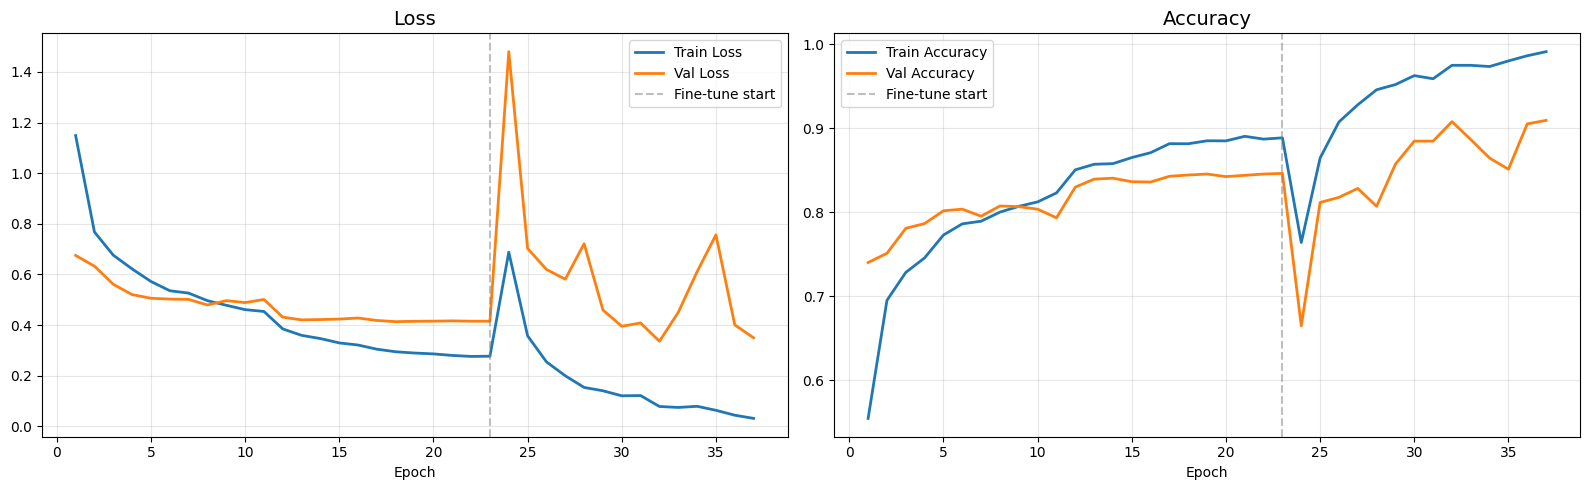

Saved ginger_training_curves.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Combine both training histories if fine-tuning was done
if 'history_fine' in dir() and history_fine is not None:
    # Explicitly cast to np.float32 to prevent mixed-precision plotting errors
    all_loss = list(np.array(history.history['loss'], dtype=np.float32)) + list(np.array(history_fine.history['loss'], dtype=np.float32))
    all_val_loss = list(np.array(history.history['val_loss'], dtype=np.float32)) + list(np.array(history_fine.history['val_loss'], dtype=np.float32))
    all_acc = list(np.array(history.history['accuracy'], dtype=np.float32)) + list(np.array(history_fine.history['accuracy'], dtype=np.float32))
    all_val_acc = list(np.array(history.history['val_accuracy'], dtype=np.float32)) + list(np.array(history_fine.history['val_accuracy'], dtype=np.float32))
    # Add a split marker
    split_epoch = len(history.history['loss'])
else:
    all_loss = np.array(history.history['loss'], dtype=np.float32)
    all_val_loss = np.array(history.history['val_loss'], dtype=np.float32)
    all_acc = np.array(history.history['accuracy'], dtype=np.float32)
    all_val_acc = np.array(history.history['val_accuracy'], dtype=np.float32)
    split_epoch = None

epochs_ran = range(1, len(all_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs_ran, all_loss,     label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, all_val_loss, label='Val Loss', linewidth=2)
if split_epoch:
    axes[0].axvline(x=split_epoch, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, all_acc,     label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_ran, all_val_acc, label='Val Accuracy', linewidth=2)
if split_epoch:
    axes[1].axvline(x=split_epoch, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ginger_training_curves.png', dpi=150)
plt.show()
print('Saved ginger_training_curves.png')


## Phase 6 — Confusion Matrix & Classification Report

Loading saved class mappings...
Extracting true labels from the optimized validation set...
Running GPU predictions on validation data...
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step


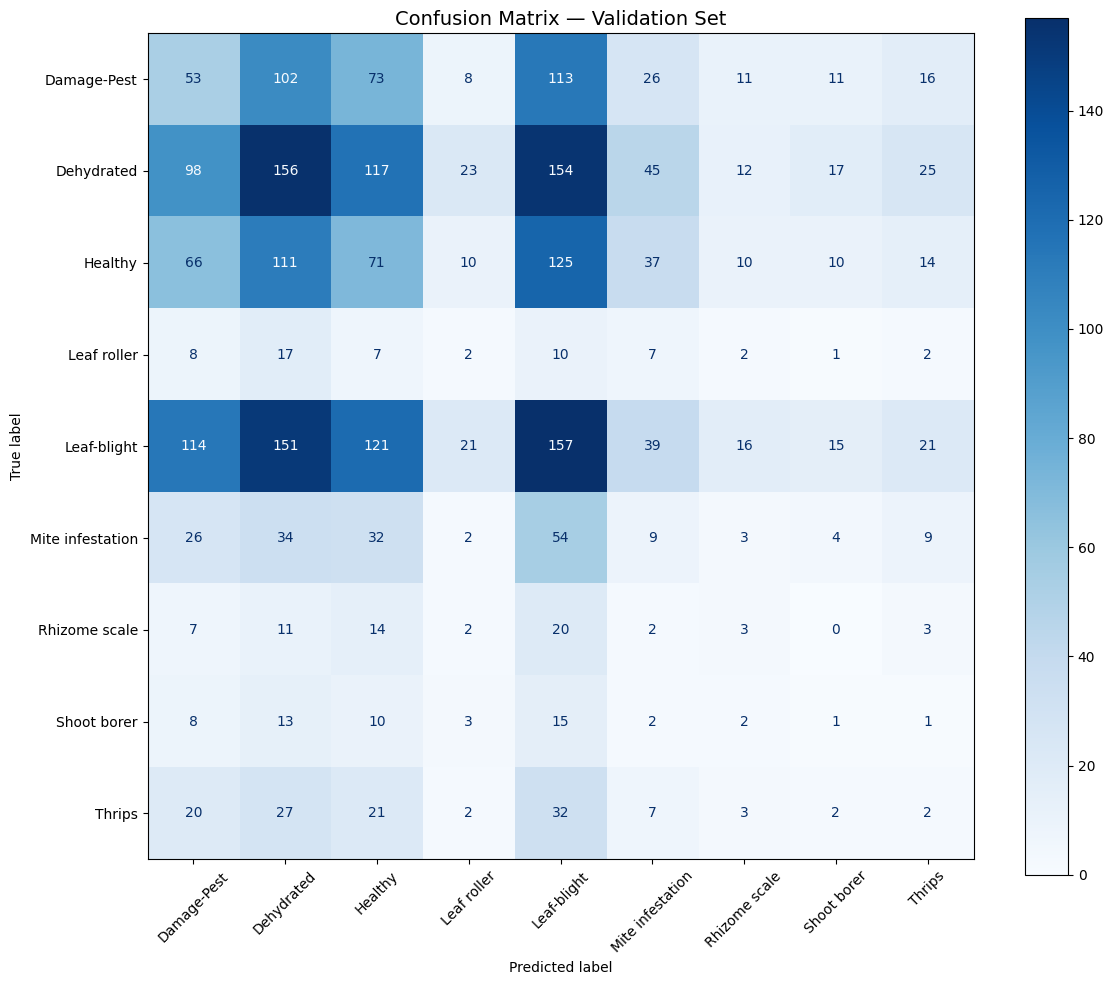


Classification Report:
                  precision    recall  f1-score   support

     Damage-Pest       0.13      0.13      0.13       413
      Dehydrated       0.25      0.24      0.25       647
         Healthy       0.15      0.16      0.15       454
     Leaf roller       0.03      0.04      0.03        56
     Leaf-blight       0.23      0.24      0.24       655
Mite infestation       0.05      0.05      0.05       173
   Rhizome scale       0.05      0.05      0.05        62
     Shoot borer       0.02      0.02      0.02        55
          Thrips       0.02      0.02      0.02       116

        accuracy                           0.17      2631
       macro avg       0.10      0.10      0.10      2631
    weighted avg       0.17      0.17      0.17      2631



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import json

# 1. Safely restore the wiped class_indices map from the JSON file we saved in Phase 2
print("Loading saved class mappings...")
with open('class_indices.json', 'r') as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}
class_names  = [idx_to_class[i] for i in sorted(idx_to_class)]

print("Extracting true labels from the optimized validation set...")
# 2. Extract the actual true class labels cleanly from our un-cached dataset
y_true = []
for _, labels in val_ds:
    # Convert categorical one-hot encoded arrays back to single integers
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

print("Running GPU predictions on validation data...")
# 3. Predict metrics directly using our memory-safe validation structure
y_pred_prob = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# --- Your existing graph generation plotting code ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — Validation Set', fontsize=14)
plt.tight_layout()
plt.savefig('ginger_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))


## Phase 7 — Sanity Test (one image from each class)

Loading saved class mappings...

Running single-image sample predictions:
True: Damage-Pest           →  Predicted: Damage-Pest           (confidence 100.0%)


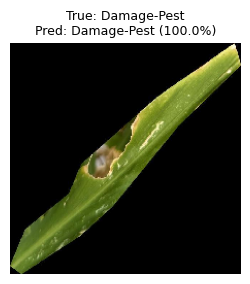

True: Dehydrated            →  Predicted: Dehydrated            (confidence 100.0%)


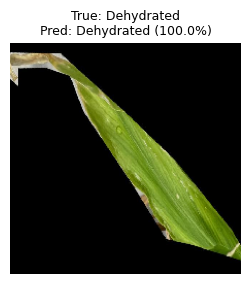

True: Healthy               →  Predicted: Healthy               (confidence 100.0%)


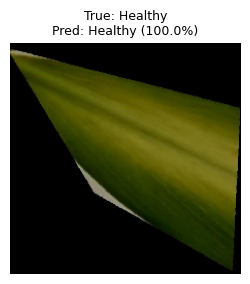

True: Leaf roller           →  Predicted: Leaf roller           (confidence 63.8%)


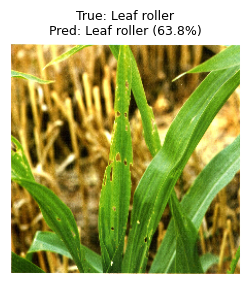

True: Leaf-blight           →  Predicted: Leaf-blight           (confidence 99.8%)


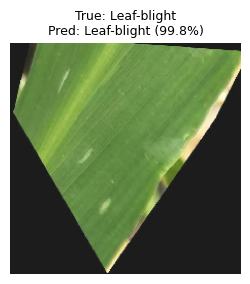

True: Mite infestation      →  Predicted: Mite infestation      (confidence 100.0%)


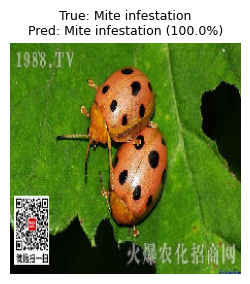

True: Rhizome scale         →  Predicted: Rhizome scale         (confidence 100.0%)


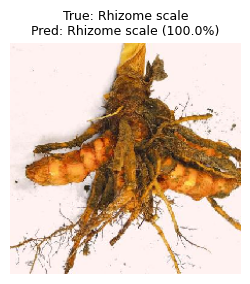

True: Shoot borer           →  Predicted: Shoot borer           (confidence 100.0%)


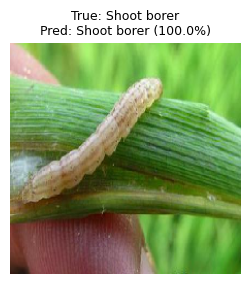

True: Thrips                →  Predicted: Thrips                (confidence 99.1%)


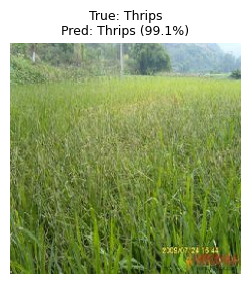

In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

# 1. Restore the wiped configuration variables locally
IMG_HEIGHT = 224
IMG_WIDTH  = 224
TRAIN_DIR = '/content/ginger_plant_dataset'

print("Loading saved class mappings...")
with open('class_indices.json', 'r') as f:
    class_indices = json.load(f)

# 2. Update prediction function to use correct MobileNetV2 scaling
def predict_one(img_path, model, class_indices):
    img = keras_image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    # CRITICAL: Replace '/ 255.0' with the official MobileNetV2 scaling function
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)

    # Cast to float16 to support the mixed precision policy we added in Phase 4b
    arr = tf.cast(arr, tf.float16)

    probs = model.predict(arr, verbose=0)[0]  # array of 9 probabilities

    # Convert float16 prediction outputs safely back to standard float32 numbers
    probs = np.array(probs, dtype=np.float32)

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    idx_to_class = {v: k for k, v in class_indices.items()}
    label = idx_to_class[pred_idx]
    return label, confidence, img

# --- Your existing visualization loop ---
print("\nRunning single-image sample predictions:")
for cls_name in sorted(class_indices.keys()):
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    if not os.path.exists(cls_dir):
        continue
    # Find first image file
    img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    samples = [f for f in os.listdir(cls_dir)
               if os.path.splitext(f)[1].lower() in img_exts]
    if not samples:
        continue
    sample = samples[0]
    img_path = os.path.join(cls_dir, sample)
    label, conf, pil_img = predict_one(img_path, model, class_indices)
    print(f'True: {cls_name:20s}  →  Predicted: {label:20s}  (confidence {conf*100:.1f}%)')
    plt.figure(figsize=(3, 3))
    plt.imshow(pil_img)
    plt.title(f'True: {cls_name}\nPred: {label} ({conf*100:.1f}%)', fontsize=9)
    plt.axis('off')
    plt.show()


## Phase 8 — Download Model

After training, place `ginger_pest_model.tflite` inside `streamlit_app/models/`.

In [14]:
import os
import tensorflow as tf
import sys

# 1. Restore the wiped configuration variables locally
MODEL_SAVE = 'ginger_pest_model.h5'
IN_COLAB = 'google.colab' in sys.modules

# Determine the best trained weights to use
best_model = MODEL_SAVE
finetuned_model = MODEL_SAVE.replace('.h5', '_finetuned.h5')

if os.path.exists(finetuned_model):
    best_model = finetuned_model
    print(f'Using fine-tuned model: {best_model}')
else:
    print(f'Using base model: {best_model}')

# Print standard Keras model metrics
model_size_mb = os.path.getsize(best_model) / (1024 * 1024)
print(f'Original Keras file size: {model_size_mb:.2f} MB')

# 2. Convert the best available model into the required TFLite format
TFLITE_OUTPUT = 'ginger_pest_model.tflite'
print("\nInitiating TFLite conversion workflow...")

try:
    # Load the trained model structure with custom mixed-precision options handled automatically
    trained_model = tf.keras.models.load_model(best_model)
    converter = tf.lite.TFLiteConverter.from_keras_model(trained_model)

    # Apply dynamic range optimization to compress the file size for Streamlit deployment
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()

    # Save the optimized binary file to the local disk
    with open(TFLITE_OUTPUT, 'wb') as f:
        f.write(tflite_model)

    tflite_size_mb = os.path.getsize(TFLITE_OUTPUT) / (1024 * 1024)
    print(f'🎉 TFLite Conversion Complete! Optimized file size: {tflite_size_mb:.2f} MB')
except Exception as e:
    print(f'❌ TFLite Conversion failed: {e}')

# 3. Handle downloding file assets cleanly out of Colab environments
if IN_COLAB:
    from google.colab import files
    print("\nTriggering downloads for your production assets...")

    # Download your final model asset for streamlit_app/models/
    if os.path.exists(TFLITE_OUTPUT):
        files.download(TFLITE_OUTPUT)
    else:
        files.download(best_model) # Fallback to original framework if conversion broke

    # Download app utilities and documentation images
    if os.path.exists('class_indices.json'):
        files.download('class_indices.json')
    if os.path.exists('ginger_training_curves.png'):
        files.download('ginger_training_curves.png')
    if os.path.exists('ginger_confusion_matrix.png'):
        files.download('ginger_confusion_matrix.png')
else:
    print(f'\nLocal run completed — Production files stored at: {os.path.abspath(os.getcwd())}')


Using fine-tuned model: ginger_pest_model_finetuned.h5
Original Keras file size: 25.16 MB

Initiating TFLite conversion workflow...


Saved artifact at '/tmp/tmp1xehg5te'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  137157347218000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347221840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347218192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347225680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347224336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347222224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347217232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347219728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347225104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137157347218576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1371573472241

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 9 — Convert to TFLite

Converts the trained Keras model to TFLite format.  
Two options:
- **Float32** (default) — best accuracy, slightly larger file
- **INT8 quantization** — smaller file, faster inference, suitable for edge/embedded devices

Download and place the `.tflite` file in `streamlit_app/models/`.

In [15]:
import os
import sys
import numpy as np
import tensorflow as tf

# 1. Restore the wiped configuration variables locally
TFLITE_SAVE = "ginger_pest_model.tflite"
TFLITE_INT8 = "ginger_pest_model_int8.tflite"
IMG_HEIGHT, IMG_WIDTH = 224, 224
NUM_CLASSES = 9
IN_COLAB = 'google.colab' in sys.modules

# Set path based on what weights are sitting on disk
if 'best_model' not in dir():
    best_model = 'ginger_pest_model_finetuned.h5' if os.path.exists('ginger_pest_model_finetuned.h5') else 'ginger_pest_model.h5'

print(f"Targeting model path for conversion: {best_model}")
model = tf.keras.models.load_model(best_model)

# ── Option 1: Float32 TFLite (no quantization) ──
print('\n--- Converting to Float32 TFLite ---')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_bytes = converter.convert()

with open(TFLITE_SAVE, 'wb') as f:
    f.write(tflite_bytes)

tflite_mb = os.path.getsize(TFLITE_SAVE) / (1024 * 1024)
print(f'Float32 TFLite: {TFLITE_SAVE}  ({tflite_mb:.2f} MB)')
assert tflite_mb > 0.5, 'TFLite file suspiciously small — check model'

# ── Option 2: INT8 Quantized TFLite (smaller, faster) ──
print('\n--- Converting to INT8 Quantized TFLite ---')

# NEW: Memory-safe representative dataset generator using our optimized val_ds dataset
def representative_dataset():
    # Take 100 sample batches from the local val_ds pipeline for calibration
    for images, _ in val_ds.take(100):
        # Convert the images to float32 arrays to calibrate the converter correctly
        yield [images.numpy().astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Configure input/output matrices to handle standard image ranges safely
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

try:
    tflite_int8_bytes = converter.convert()
    with open(TFLITE_INT8, 'wb') as f:
        f.write(tflite_int8_bytes)
    int8_mb = os.path.getsize(TFLITE_INT8) / (1024 * 1024)
    print(f'INT8 TFLite: {TFLITE_INT8}  ({int8_mb:.2f} MB)')
    print(f'  Compression ratio: {tflite_mb / int8_mb:.1f}x smaller')
except Exception as e:
    print(f'INT8 quantization failed: {e}')
    print('Skipping INT8 — float32 model is still available.')

# ── Sanity check: run dummy inference through float32 TFLite ──
print('\n--- Sanity Check ---')
tflite_interp = tf.lite.Interpreter(model_path=TFLITE_SAVE)
tflite_interp.allocate_tensors()
inp_det = tflite_interp.get_input_details()
out_det = tflite_interp.get_output_details()

print(f'Input shape:  {inp_det[0]["shape"]}')
print(f'Output shape: {out_det[0]["shape"]}  (should be [1, 9])')
assert out_det[0]['shape'][1] == NUM_CLASSES, \
    f'Output layer has {out_det[0]["shape"][1]} classes, expected {NUM_CLASSES}'

dummy = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
tflite_interp.set_tensor(inp_det[0]['index'], dummy)
tflite_interp.invoke()
tflite_out = tflite_interp.get_tensor(out_det[0]['index'])[0]
print(f'Dummy inference output shape: {tflite_out.shape}')
print(f'Class probabilities: {np.round(tflite_out, 3)}')
print(f'Sum of probabilities: {np.sum(tflite_out):.4f}  (should be ~1.0)')
print('\nTFLite sanity check passed!')

if IN_COLAB:
    from google.colab import files
    print("\nTriggering downloads for production models...")
    files.download(TFLITE_SAVE)
    if os.path.exists(TFLITE_INT8):
        files.download(TFLITE_INT8)
    print(f'\nDownloaded — place the desired model in your streamlit_app/models/ folder')
else:
    print(f'\nLocal run — TFLite models saved to:')
    print(f'  {os.path.abspath(TFLITE_SAVE)}')
    if os.path.exists(TFLITE_INT8):
        print(f'  {os.path.abspath(TFLITE_INT8)}')


Targeting model path for conversion: ginger_pest_model_finetuned.h5



--- Converting to Float32 TFLite ---
Saved artifact at '/tmp/tmpnjudiu1v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  137157347225296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550878672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550879056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550875024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550878096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550873872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550878480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550878288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550878864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137152550876752: TensorSpec(shape=(), dtype=t

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite: ginger_pest_model_int8.tflite  (2.95 MB)
  Compression ratio: 3.3x smaller

--- Sanity Check ---
Input shape:  [  1 224 224   3]
Output shape: [1 9]  (should be [1, 9])
Dummy inference output shape: (9,)
Class probabilities: [0.002 0.022 0.796 0.002 0.154 0.007 0.    0.    0.017]
Sum of probabilities: 1.0000  (should be ~1.0)

TFLite sanity check passed!

Triggering downloads for production models...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded — place the desired model in your streamlit_app/models/ folder


## Phase 10 — Copy TFLite to Streamlit App

Run this cell to automatically copy the TFLite model into the Streamlit app's models folder.

In [16]:
import os
import sys

# 1. Restore the missing configuration variables locally
IN_COLAB = 'google.colab' in sys.modules

# Define project_root safely in case this is running on a local machine
try:
    if 'project_root' not in dir():
        project_root = os.path.dirname(os.getcwd())  # Go up from notebooks/
except Exception:
    project_root = os.getcwd()

# --- Your existing file copy & path detection logic ---
if not IN_COLAB:
    import shutil

    # Detect the streamlit app models directory
    possible_paths = [
        os.path.join(project_root, 'streamlit_app', 'models'),
        os.path.join(os.getcwd(), '..', 'streamlit_app', 'models'),
        os.path.join(os.getcwd(), 'streamlit_app', 'models'),
    ]

    app_models_dir = None
    for p in possible_paths:
        resolved = os.path.abspath(p)
        if os.path.exists(resolved):
            app_models_dir = resolved
            break

    if app_models_dir:
        # Copy float32 model
        dst = os.path.join(app_models_dir, TFLITE_SAVE)
        shutil.copy2(TFLITE_SAVE, dst)
        print(f'✓ Copied {TFLITE_SAVE} → {dst}')

        # Copy INT8 model if it exists
        if os.path.exists(TFLITE_INT8):
            dst_int8 = os.path.join(app_models_dir, TFLITE_INT8)
            shutil.copy2(TFLITE_INT8, dst_int8)
            print(f'✓ Copied {TFLITE_INT8} → {dst_int8}')

        # Copy class indices
        dst_idx = os.path.join(app_models_dir, 'class_indices.json')
        shutil.copy2('class_indices.json', dst_idx)
        print(f'✓ Copied class_indices.json → {dst_idx}')
    else:
        print('⚠ Could not find streamlit_app/models/ directory.')
        print(f'  Manually copy these files to streamlit_app/models/:')
        print(f'    - {os.path.abspath(TFLITE_SAVE)}')
        if os.path.exists(TFLITE_INT8):
            print(f'    - {os.path.abspath(TFLITE_INT8)}')
        print(f'    - {os.path.abspath("class_indices.json")}')
else:
    print('🎉 Colab run complete!')
    print('Download the files generated in Phase 9 and manually place them in your streamlit_app/models/ folder.')


🎉 Colab run complete!
Download the files generated in Phase 9 and manually place them in your streamlit_app/models/ folder.
